In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Subset Olink RVAT significant

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o /home/dnanexus/data_dir/

olink_whitelist = (
    pl.read_parquet(f'/home/dnanexus/data_dir/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o /home/dnanexus/data_dir/

olink_corrs = (
    pl.read_parquet(f'/home/dnanexus/data_dir/{olink_correlations_file}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir/proteomics_prs_df_loftee_mac20_burden_reg
ression_results.parquet" already exists but -f/--overwrite was not set
Error: path
"/home/dnanexus/data_dir/olink_all_mac20_lofteeHC_correlations.parquet"
already exists but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000163606""","""ENSG00000163606_olink""",0.204082,0.204082,1.0
"""ENSG00000144857""","""ENSG00000144857_olink""",0.162616,0.162616,1.0
"""ENSG00000161270""","""ENSG00000161270_olink""",0.175562,0.175562,1.0
"""ENSG00000091129""","""ENSG00000091129_olink""",0.165924,0.165924,1.0
"""ENSG00000132437""","""ENSG00000132437_olink""",0.214824,0.214824,1.0
…,…,…,…,…
"""ENSG00000101160""","""ENSG00000101160_olink""",0.386419,0.386419,1.0
"""ENSG00000130528""","""ENSG00000130528_olink""",0.305544,0.305544,1.0
"""ENSG00000110448""","""ENSG00000110448_olink""",0.337765,0.337765,1.0


In [3]:
# Configuration and paths
mac = 20
abs_phenotypes = False
# abs_phenotypes = True

# Initialize new annotation variable as None
new_anno_local = None

# Load annotation configuration
if abs_phenotypes:
    config_path = "/home/dnanexus/ukbgym/config_odds.yaml" # If abs_pheno then deleteriousness direction
else:    
    config_path = "/home/dnanexus/ukbgym/config_olink_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
…,…,…,…,…
"""regulatory""","""fz_blood_min""","""crimson""","""Flashzoi min across RNA (blood…",-1
"""regulatory""","""fz_all_min""","""#FFA500""","""Flashzoi min across RNA (all)""",-1
"""regulatory""","""fz_blood_max""","""crimson""","""Flashzoi max across RNA (blood…",1


In [4]:
new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv39_avg_ukbbgym.parquet"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv39_0_ukbbgym.parquet"
new_anno_filename = "ukbbgym_TSS_promoter_enhancer_TF_variants_all_260218_0_ukbbgym.parquet"
!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = (
    pl.scan_parquet(new_anno_local)
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .with_columns(
        # fz_all_mean = pl.mean_horizontal(cs.starts_with('RNA:').abs()),
        # fz_blood_mean = pl.mean_horizontal(pl.col(['RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533']).abs()),
        fz_blood_min = pl.min_horizontal(pl.col(['RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533'])),
        fz_all_min = pl.min_horizontal(cs.starts_with('RNA:')),
        fz_blood_max = pl.max_horizontal(pl.col(['RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533'])),
        fz_all_max = pl.max_horizontal(cs.starts_with('RNA:')),
    )
    .select(['id', 'region', 'fz_blood_min', 'fz_all_min', 'fz_blood_max', 'fz_all_max'])
    .collect()
)

new_anno_df

[===========================================================>] Completed 13,604,583,227 of 13,604,583,227 bytes (100%) /home/dnanexus/data_dir/ukbbgym_TSS_promoter_enhancer_TF_variants_all_260218_0_ukbbgym.parquett=============>                                             ] Downloaded 3,338,665,984 of 13,604,583,227 bytes (24%) /home/dnanexus/data_dir/ukbbgym_TSS_promoter_enhancer_TF_variants_all_260218_0_ukbbgym.parquet


/tmp/ipykernel_302886/2244126634.py:21: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,fz_blood_min,fz_all_min,fz_blood_max,fz_all_max
str,str,f32,f32,f32,f32
"""chr20:44726245:G:A""","""ENSG00000064205""",-0.001006,-0.006898,-0.000016,0.001423
"""chr7:8251452:T:C""","""ENSG00000003147""",-0.000939,-0.013746,-0.000166,0.019601
"""chr12:10309195:A:G""","""ENSG00000134539""",0.002081,-0.01001,0.019411,0.074744
"""chr11:72001570:A:G""","""ENSG00000137496""",-0.013965,-0.044438,-0.005774,0.038135
"""chr2:162198524:G:A""","""ENSG00000078098""",0.00508,-0.002404,0.007588,0.021105
…,…,…,…,…,…
"""chr17:1645491:A:C""","""ENSG00000074660""",-0.017778,-0.033511,-0.001122,0.107099
"""chr12:56007826:G:T""","""ENSG00000139531""",-0.004501,-0.021009,-0.002234,0.002934
"""chr6:159982939:G:A""","""ENSG00000197081""",-0.008397,-0.008397,-0.003122,0.002198


In [5]:
new_anno_df['region'].unique()

region
str
"""ENSG00000143799"""
"""ENSG00000123609"""
"""ENSG00000172432"""
"""ENSG00000256269"""
"""ENSG00000125726"""
…
"""ENSG00000105221"""
"""ENSG00000196352"""
"""ENSG00000173482"""


In [6]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# If True, fillna variants are kept but ranked at the bottom of each annotation
keep_fillna = True  

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df.lazy(),
            on=['id', 'region'],
            how='left'
        )
    )

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Olink whitelist
        (pl.col('region').is_in(olink_whitelist['region'].unique())),
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),
        
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # VEP consequences
        # (pl.col('consequence_missense_variant') == True),

        # Choose protein domain
        # (pl.col('ted_domain') == True),
        # (pl.col('mobi_curated_disorder_priority') == True),
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('low_complexity_domain') == True),

        # Choose non CDS only
        # UPDATE WITH NEW VEP MANE ANNOS
        ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),

        # Choose Introns with/without alternate CDS
        # (pl.col('consequence_intron_variant') == True),

        # Core promoter
        # (pl.col('promoterai_is_na') == False),

        # Choose regulatory region
        (pl.col('encode_any_tf') == True),
        # (pl.col('encode_enhancer') == True),
        # (pl.col('encode_promoter') == True),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
        promoterai_under = pl.col('promoterai'),
        promoterai_over = pl.col('promoterai'),
    )
)

# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'regulatory_nondir'] # CDS
# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # missense
# selected_categories = ['genetic_diversity', 'conservation', 'naive']    # plof comparison
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['genetic_diversity', 'conservation', 'regulatory', 'regulatory_nondir'] # promoter
selected_categories = ['genetic_diversity', 'splicing', 'conservation', 'regulatory', 'regulatory_nondir', '3utr'] # non coding
# selected_categories = ['genetic_diversity', 'splicing', 'conservation'] # introns

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_302886/1697276317.py:89: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_302886/1697276317.py:98: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


delta_score,absplice_dna_max,region,gpn_score,abexp_min,promoterai,fz_blood_min,fz_all_max,verphylop,id,fz_blood_max,aparent2,abexp_max,promoterai_under,pangolin_score,cadd_raw,promoterai_over,absplice2_max,fz_all_min
f32,f32,str,f32,f32,f32,f32,f32,f32,str,f32,f32,f32,f32,f32,f32,f32,f32,f32
0.0,0.001,"""ENSG00000007908""",-3.09,-0.019552,0.0,0.00563,0.018909,-0.112,"""chr1:169726383:G:T""",0.009515,0.0,0.006871,0.0,0.0,0.102994,0.0,0.000033,-0.007356
0.0,0.001,"""ENSG00000150540""",1.4,-0.005501,0.0,0.000096,0.003081,0.327,"""chr2:137977961:C:T""",0.0004,0.0,0.0,0.0,0.0,0.020952,0.0,0.000033,-0.001177
0.0,0.001,"""ENSG00000065613""",-0.08,-0.006286,0.0,0.000752,0.002604,0.203,"""chr10:103977444:C:T""",0.001228,0.0,-0.004967,0.0,0.0,0.247548,0.0,0.000033,-0.00041
0.0,0.0,"""ENSG00000163661""",-0.94,-0.019552,0.0,0.000683,0.016258,-1.521,"""chr3:157448377:T:C""",0.001719,0.0,0.002469,0.0,0.0,-0.108573,0.0,0.0,-0.004873
0.0,0.0,"""ENSG00000163661""",-0.94,-0.019552,0.0,0.000683,0.016258,-1.521,"""chr3:157448377:T:C""",0.001719,0.0,0.002469,0.0,0.0,-0.108573,0.0,0.0,-0.004873
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.001,"""ENSG00000091129""",0.35,-0.006438,0.0,0.000097,0.002426,0.327,"""chr7:108213150:T:A""",0.000615,0.0,0.007069,0.0,0.0,0.137093,0.0,0.000033,-0.000432
0.0,0.001,"""ENSG00000015413""",-0.36,-0.019552,0.0,0.000721,0.017005,-0.042,"""chr16:89631833:G:A""",0.003433,0.0,0.0,0.0,0.0,0.154314,0.0,0.000033,-0.040637
0.0,0.0,"""ENSG00000136026""",-1.47,0.001765,0.0,0.000226,0.003497,-0.247,"""chr12:106267705:G:T""",0.000862,0.0,0.003182,0.0,0.0,0.900161,0.0,0.000033,-0.005195


In [7]:
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in selected_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_302886/3323645961.py:28: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr5:84163974:T:C""","""ENSG00000164176""","""absplice_dna_max""",1
"""chr6:157758264:A:C""","""ENSG00000130340""","""absplice_dna_max""",1
"""chr3:133780116:A:C""","""ENSG00000091513""","""absplice_dna_max""",1
"""chr3:2151447:T:A""","""ENSG00000144619""","""absplice_dna_max""",1
"""chr1:169713315:A:G""","""ENSG00000188404""","""absplice_dna_max""",1


In [8]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Keep variants that don't have fillna annotation (skip if keep_fillna=True)
    .pipe(lambda df: df if keep_fillna else df.join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    ))

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        # annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="min", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr11:20959558:A:C""","""ENSG00000165973""","""absplice2_max""",0.0,"""splicing""",1,189314.0
"""chr7:87946101:T:C""","""ENSG00000008277""","""absplice2_max""",0.000033,"""splicing""",1,36373.0
"""chr3:78834438:A:G""","""ENSG00000169855""","""absplice2_max""",0.0,"""splicing""",1,189314.0
"""chr19:50825414:T:G""","""ENSG00000174562""","""absplice2_max""",0.000033,"""splicing""",1,36373.0
"""chr2:47343009:C:A""","""ENSG00000119888""","""absplice2_max""",0.0,"""splicing""",1,189314.0
…,…,…,…,…,…,…
"""chr4:101615779:G:A""","""ENSG00000153064""","""absplice2_max""",0.0,"""splicing""",1,189314.0
"""chr6:151244830:G:A""","""ENSG00000131016""","""absplice2_max""",0.000033,"""splicing""",1,36373.0
"""chr4:7692193:C:T""","""ENSG00000184985""","""absplice2_max""",0.000033,"""splicing""",1,36373.0


In [9]:
melted_anno['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""absplice2_max""",287433
"""gpn_score""",287433
"""delta_score""",287433
"""cadd_raw""",287433
"""promoterai""",287433
…,…
"""pangolin_score""",287433
"""fz_all_min""",248935
"""fz_all_max""",248935


In [10]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Merge phenotype data and annotation data
olink_appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

Error: path "/home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_app
v_percentiles_small_desc.parquet" already exists but -f/--overwrite was not
set


In [11]:
olink_appv.head().collect()

id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr12:24805471:G:A""","""ENSG00000060982_olink""",0.328067,1
"""chr12:122768837:C:G""","""ENSG00000139726_olink""",-1.312343,1
"""chr2:102332039:T:C""","""ENSG00000115604_olink""",0.249114,1
"""chr2:37346399:G:A""","""ENSG00000115828_olink""",1.00197,1
"""chr16:89195863:C:G""","""ENSG00000129910_olink""",-0.059154,1


## Odds ratio computation

In [ ]:
n_steps = 101
min_rank_cutoff = 1_00
max_rank_cutoff = 20_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])

# quant_threshold = 0.9
# zscore_threshold = stats.norm.ppf(quant_threshold) #phenotype percentile threshold to z-score (assuming standard Gaussian)
# print(f"Phenotype threshold: {quant_threshold} → z-score: {zscore_threshold:.4f}")

# zscore_threshold = -0.448126  #Obtained from LOFTEE_avg_effect_olink.ipynb
# zscore_threshold = -2.100129  #Obtained from LOFTEE_avg_effect_olink.ipynb
zscore_threshold = -2.287918   #Obtained from LOFTEE_avg_effect_olink.ipynb

extreme_pheno_dir = 'bottom' if zscore_threshold < 0 else 'top'
print(f"Extreme phenotype direction: {extreme_pheno_dir}")

quant_threshold = stats.norm.sf(zscore_threshold) if zscore_threshold < 0 else stats.norm.cdf(zscore_threshold)
print(f"z-score: {zscore_threshold:.4f} --> Quantile threshold: {quant_threshold:.4f}")

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

# Prepare cutoffs once
cutoffs_sorted = (
    pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})
    .with_columns(pl.col('rank_cutoff').cast(pl.Float32))
    .sort('rank_cutoff')
    .collect()
)

cutoffs_sorted

Extreme phenotype direction: bottom
z-score: -2.1001 --> Quantile threshold: 0.9821


rank_cutoff
f32
100.0
108.0
117.0
127.0
137.0
…
214576.0
232427.0
251762.0


In [13]:
# --- Pre-aggregate per-(region, annotation, rank_cutoff) counts, then bootstrap ---
# We assume mean_pheno_value ~ N(0,1). Extreme = z-score > zscore_threshold.
# Bootstrap across gene-trait pairs to get CIs that account for non-independence.

id_region = anno.select(['id', 'region']).unique().lazy()

# Stream-collect base data ONCE: compute is_extreme using z-score threshold
gp_base = (
    olink_appv
    .join(id_region, on='id', how='inner')
    .join(olink_whitelist.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        is_extreme = (
            pl.when(extreme_pheno_dir == 'bottom')
                .then(pl.col('mean_pheno_value') <= zscore_threshold)
                .otherwise(pl.col('mean_pheno_value') >= zscore_threshold)
        )
    )
    .select(['id', 'region', 'is_extreme'])
    .collect(engine='streaming')
)

print(f"gp_base: {gp_base.shape}, extreme: {gp_base['is_extreme'].sum()}")

# --- Step 1: Pre-aggregate per (region, annotation, rank_cutoff) 2x2 table counts ---
all_regions = sorted(olink_whitelist['region'].unique().to_list())
n_regions = len(all_regions)
all_regions_df = pl.DataFrame({'region': all_regions})

annotations_list = sorted(melted_anno['annotation'].unique().to_list())
n_annotations = len(annotations_list)
n_cutoffs = cutoffs_sorted.shape[0]

# 4D array: (n_annotations, n_regions, n_cutoffs, 4)
# 4 = [n_dis_above, n_notdis_above, n_dis_below, n_notdis_below]
counts_4d = np.zeros((n_annotations, n_regions, n_cutoffs, 4), dtype=np.int64)

for a_idx, annotation in enumerate(tqdm(annotations_list, desc='Pre-aggregating')):
    anno_ranks = (
        melted_anno
        .filter(pl.col('annotation') == annotation)
        .select(['id', 'region', 'annotation_score_dircor_rank_desc'])
    )

    # Group by (region, rank), count extreme vs total
    region_rank_counts = (
        gp_base.lazy()
        .join(anno_ranks.lazy(), on=['id', 'region'], how='inner')
        .group_by(['region', 'annotation_score_dircor_rank_desc'])
        .agg(
            n_extreme = pl.col('is_extreme').sum().cast(pl.Int64),
            n_total = pl.len().cast(pl.Int64),
        )
        .collect()
        .sort(['region', 'annotation_score_dircor_rank_desc'])
        .with_columns(
            cum_extreme = pl.col('n_extreme').cum_sum().over('region'),
            cum_total = pl.col('n_total').cum_sum().over('region'),
        )
    )

    # Per-region totals
    region_totals = (
        region_rank_counts
        .group_by('region')
        .agg(
            total_extreme = pl.col('n_extreme').sum(),
            total_count = pl.col('n_total').sum(),
        )
    )

    # Cross join cutoffs × ALL regions, then asof join by region
    per_region = (
        cutoffs_sorted
        .join(all_regions_df, how='cross')
        .sort(['region', 'rank_cutoff'])
        .join_asof(
            region_rank_counts.sort(['region', 'annotation_score_dircor_rank_desc']),
            left_on='rank_cutoff',
            right_on='annotation_score_dircor_rank_desc',
            by='region',
            strategy='backward',
        )
        .with_columns(
            cum_extreme = pl.col('cum_extreme').fill_null(0),
            cum_total = pl.col('cum_total').fill_null(0),
        )
        .join(region_totals, on='region', how='left')
        .with_columns(
            total_extreme = pl.col('total_extreme').fill_null(0),
            total_count = pl.col('total_count').fill_null(0),
        )
        .with_columns(
            n_dis_above = pl.col('cum_extreme'),
            n_notdis_above = pl.col('cum_total') - pl.col('cum_extreme'),
            n_dis_below = pl.col('total_extreme') - pl.col('cum_extreme'),
            n_notdis_below = (pl.col('total_count') - pl.col('total_extreme'))
                           - (pl.col('cum_total') - pl.col('cum_extreme')),
        )
        .sort(['region', 'rank_cutoff'])
    )

    # Vectorized fill: sorted by (region, rank_cutoff), reshape to (n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 0] = per_region['n_dis_above'].to_numpy().reshape(n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 1] = per_region['n_notdis_above'].to_numpy().reshape(n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 2] = per_region['n_dis_below'].to_numpy().reshape(n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 3] = per_region['n_notdis_below'].to_numpy().reshape(n_regions, n_cutoffs)

print(f"Pre-aggregated: {counts_4d.shape} = {n_annotations} annos × {n_regions} regions × {n_cutoffs} cutoffs × 4 counts")
print(f"Memory: {counts_4d.nbytes / 1e6:.1f} MB")

# --- Step 2: Point estimate (sum across all regions) ---
total_counts = counts_4d.sum(axis=1)  # (n_annotations, n_cutoffs, 4)
with np.errstate(divide='ignore', invalid='ignore'):
    point_or = (total_counts[:, :, 0] / total_counts[:, :, 1]) / \
               (total_counts[:, :, 2] / total_counts[:, :, 3])

# --- Step 3: Bootstrap CIs across gene-trait pairs ---
n_boot = 1000
rng = np.random.default_rng(42)
boot_ors = np.full((n_boot, n_annotations, n_cutoffs), np.nan)

for b in tqdm(range(n_boot), desc='Bootstrapping'):
    idx = rng.choice(n_regions, size=n_regions, replace=True)
    sampled = counts_4d[:, idx, :, :].sum(axis=1)  # (n_annotations, n_cutoffs, 4)
    with np.errstate(divide='ignore', invalid='ignore'):
        boot_ors[b] = (sampled[:, :, 0] / sampled[:, :, 1]) / (sampled[:, :, 2] / sampled[:, :, 3])

# 95% CIs (percentile method — no log transform needed since percentiles are monotone-invariant)
boot_ci_lower = np.nanpercentile(boot_ors, 2.5, axis=0)
boot_ci_upper = np.nanpercentile(boot_ors, 97.5, axis=0)

# --- Build output DataFrame ---
cutoff_values = cutoffs_sorted['rank_cutoff'].to_numpy()
anno_idx, cutoff_idx = np.meshgrid(np.arange(n_annotations), np.arange(n_cutoffs), indexing='ij')

or_df = (
    pl.DataFrame({
        'annotation': np.array(annotations_list)[anno_idx.ravel()],
        'rank_cutoff': cutoff_values[cutoff_idx.ravel()],
        'n_dis_above': total_counts[:, :, 0].ravel(),
        'n_notdis_above': total_counts[:, :, 1].ravel(),
        'n_dis_below': total_counts[:, :, 2].ravel(),
        'n_notdis_below': total_counts[:, :, 3].ravel(),
        'odds_ratio': point_or.ravel(),
        'ci_lower': boot_ci_lower.ravel(),
        'ci_upper': boot_ci_upper.ravel(),
    })
    .filter(pl.col('odds_ratio').is_finite() & (pl.col('odds_ratio') > 0))
    .sort('rank_cutoff', descending=True)
)

print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())
or_df

gp_base: (63338, 3), extreme: 868


Pre-aggregating: 100%|██████████| 17/17 [00:01<00:00, 12.47it/s]


Pre-aggregated: (17, 1119, 101, 4) = 17 annos × 1119 regions × 101 cutoffs × 4 counts
Memory: 61.5 MB


Bootstrapping: 100%|██████████| 1000/1000 [00:26<00:00, 37.04it/s]
/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered


unique percentile cutoffs: 100


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract


annotation,rank_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,odds_ratio,ci_lower,ci_upper
str,f32,i64,i64,i64,i64,f64,f64,f64
"""abexp_max""",272706.0,838,59948,30,2522,1.17515,0.82014,1.838261
"""abexp_min""",272706.0,827,59242,41,3228,1.09907,0.818508,1.600323
"""aparent2""",272706.0,856,61901,12,569,0.655703,0.395304,1.347218
"""cadd_raw""",272706.0,830,59153,38,3317,1.224794,0.89766,1.8117
"""gpn_score""",272706.0,817,58782,51,3688,1.005075,0.768358,1.3764
…,…,…,…,…,…,…,…,…
"""gpn_score""",100.0,1,22,867,62448,3.273986,0.0,11.22705
"""pangolin_score""",100.0,2,14,866,62456,10.30287,0.0,34.285547
"""promoterai""",100.0,1,22,867,62448,3.273986,0.0,10.701496


## Plotting

In [14]:
plt_df = (
    or_df
    .drop_nans()
    .filter(
        pl.col('odds_ratio').is_finite(),
        pl.col('odds_ratio') > 0,
        pl.col('ci_lower') > 0,
        # pl.col('n_dis_above_cutoff')>1,
        # pl.col('n_dis_below_cutoff')>1,
        # pl.col('n_notdis_above_cutoff')>1,
        # pl.col('n_notdis_below_cutoff')>1,
    )

    .with_columns(
        log_rank_cutoff = pl.col('rank_cutoff').log10(),
        log_rank_cutoff_inv = (1 / pl.col('rank_cutoff')).log10(),
    )
    .join(
        anno_config_df.filter(pl.col('category').is_in(selected_categories)).select(['annotation', 'color', 'label', 'category']).unique(),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('log_rank_cutoff')
)

plt_df

annotation,rank_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,odds_ratio,ci_lower,ci_upper,log_rank_cutoff,log_rank_cutoff_inv,color,label,category
str,f32,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,str
"""delta_score""",282.0,4,68,864,62402,4.248502,0.924053,9.008513,2.450249,-2.450249,"""#8BC34A""","""SpliceAI""","""splicing"""
"""delta_score""",306.0,4,72,864,62398,4.012217,0.884142,8.36667,2.485721,-2.485721,"""#8BC34A""","""SpliceAI""","""splicing"""
"""delta_score""",331.0,4,79,864,62391,3.656294,0.809643,7.542312,2.519828,-2.519828,"""#8BC34A""","""SpliceAI""","""splicing"""
"""delta_score""",359.0,4,89,864,62381,3.244954,0.734198,6.661225,2.555094,-2.555094,"""#8BC34A""","""SpliceAI""","""splicing"""
"""delta_score""",389.0,4,102,864,62368,2.830792,0.660721,5.885691,2.58995,-2.58995,"""#8BC34A""","""SpliceAI""","""splicing"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""aparent2""",272706.0,856,61901,12,569,0.655703,0.395304,1.347218,5.435695,-5.435695,"""#FFA500""","""Aparent 2""","""3utr"""
"""cadd_raw""",272706.0,830,59153,38,3317,1.224794,0.89766,1.8117,5.435695,-5.435695,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""gpn_score""",272706.0,817,58782,51,3688,1.005075,0.768358,1.3764,5.435695,-5.435695,"""pink""","""GPN-MSA""","""conservation"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


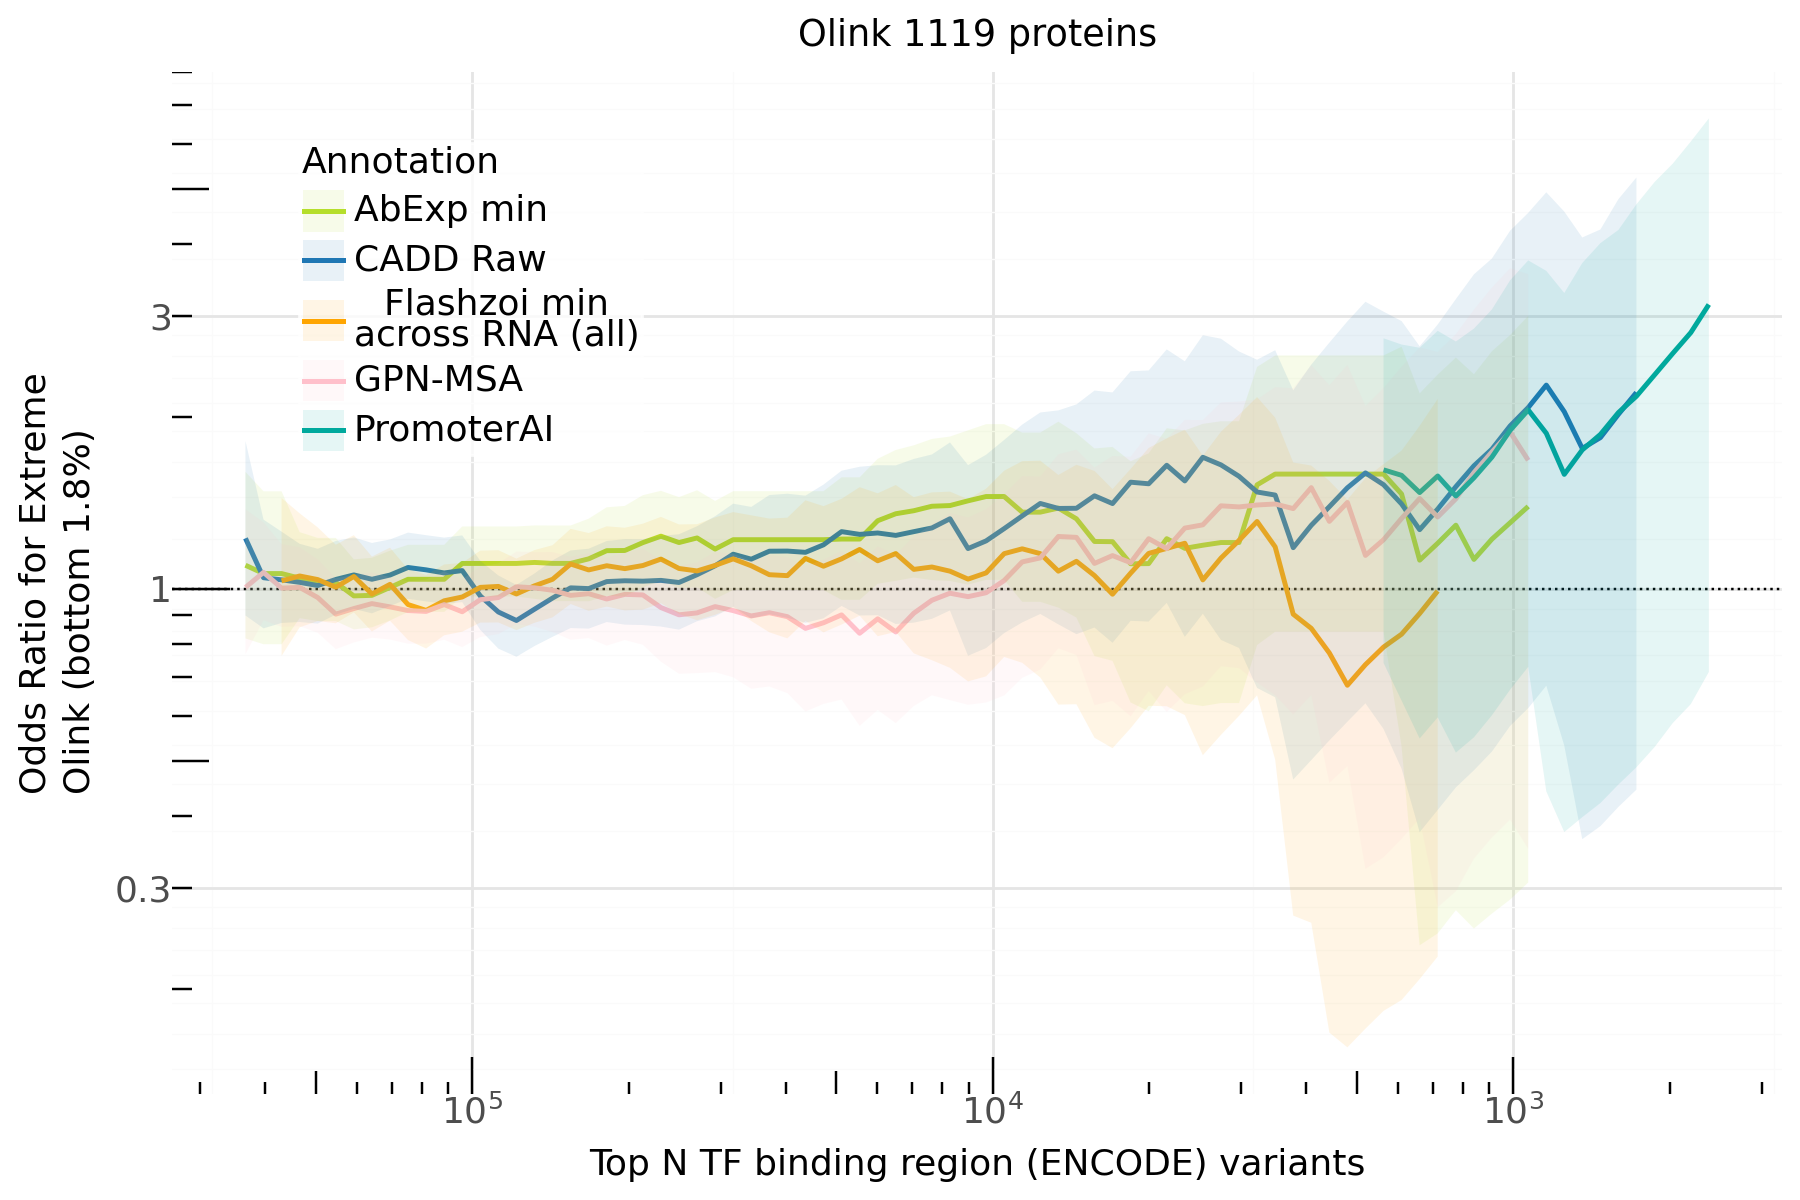

In [ ]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('log_rank_cutoff_inv') >= -5.5),
        (pl.col('log_rank_cutoff_inv') <= -2.4),

        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_score', 'absplice2_max', 'abexp_abs_max', 'cadd_raw']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense', 'score_pai3d', 'gpn_score', 'verphylop']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'pangolin_score', 'delta_score', 'absplice2_max']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs', 'fz_RNA_blood_abs_max', 'fz_RNA_all_abs_max']))
        # (pl.col('annotation').is_in(['delta_score', 'pangolin_score', 'absplice_dna_max', 'absplice2_max', 'gpn_score', 'verphylop']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'abexp_min', 'pangolin_score', 'fz_all_min']))
        (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'abexp_min', 'promoterai_under', 'fz_all_min']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'abexp_min', 'promoterai_over', 'fz_all_max']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"$10^{{{int(-b)}}}$" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))
# pheno_label = f"{extreme_pheno_dir} {round((1 - quant_threshold) * 100, 1)}%"
if extreme_pheno_dir == 'bottom':
    pheno_label = f"Z < {round(zscore_threshold, 2)}"
else:
    pheno_label = f"Z > {round(zscore_threshold, 2)}"

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    # + loftee_point
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"Olink {olink_whitelist.shape[0]} proteins",
        y=f"Odds Ratio for Extreme\nOlink ({pheno_label})",
        x=f"Top N TF binding region (ENCODE) variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(9, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.1, 0.9), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [16]:
plt_df.filter(
    pl.col('annotation')=='promoterai_under',
    pl.col('rank_cutoff')>1_000_000
)

annotation,rank_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,odds_ratio,ci_lower,ci_upper,log_rank_cutoff,log_rank_cutoff_inv,color,label,category
str,f32,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,str
